# Machine_Learning_Assignment_2_by_student_TalaSahmoud_2320221189

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
os.makedirs('data', exist_ok=True)

!cp "/content/drive/MyDrive/ML_Assignment2/marketing_campaign.csv" "data/"

In [7]:
import pandas as pd

df = pd.read_csv('data/marketing_campaign.csv', sep='\t')
df.head() # لعرض أول 5 أسطر

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


# Data Preprocessing

# 1.Inspection & Imputation

In [8]:
#  فحص القيم المفقودة لمعرفتها قبل التعويض
print("القيم المفقودة قبل التعويض:")
print(df.isnull().sum())

# تعويض القيم المفقودة في عمود Income باستخدام الوسيط (Median)
income_median = df['Income'].median()
df['Income'] = df['Income'].fillna(income_median)

print("القيم المفقودة في عمود Income بعد التعويض:", df['Income'].isnull().sum())

القيم المفقودة قبل التعويض:
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64
القيم المفقودة في عمود Income بعد التعويض: 0


# 2.Feature Engineering

In [10]:
# حساب العمر (بناءً على السنة الحالية 2026)
df['Age'] = 2026 - df['Year_Birth']

#حساب إجمالي الإنفاق عبر جمع الأعمدة الستة المحددة
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['TotalSpending'] = df[spending_cols].sum(axis=1)

#حساب إجمالي الأطفال في المنزل
df['TotalChildren'] = df['Kidhome'] + df['Teenhome']

df[['Year_Birth', 'Age', 'TotalSpending', 'TotalChildren']].head()

,Year_Birth,Age,TotalSpending,TotalChildren
0,1957,69,1617,0
1,1954,72,27,2
2,1965,61,776,0
3,1984,42,53,1
4,1981,45,422,1


# 3.Filtering

In [11]:
#  حجم البيانات قبل التصفية
print("حجم البيانات الأصلي:", df.shape)

# التصفية: إبقاء الأعمار بين 18 و 100 سنة، والدخل أكبر من صفر
df = df[(df['Age'] >= 18) & (df['Age'] <= 100)]
df = df[df['Income'] > 0]

#  حجم البيانات بعد التصفية
print("حجم البيانات بعد التصفية وحذف القيم الشاذة:", df.shape)

حجم البيانات الأصلي: (2240, 32)
حجم البيانات بعد التصفية وحذف القيم الشاذة: (2237, 32)


# 4.Encoding

In [12]:
#  تLabel Encoding
education_mapping = {"Basic": 0, "Graduation": 1, "Master": 2, "PhD": 3}
# أحياناً يكون هناك فئة "2n Cycle"، سنعاملها كـ Graduation أو نضعها كـ 1
df['Education'] = df['Education'].map(education_mapping).fillna(1).astype(int)

#  One-Hot Encoding
# تحديد أعلى 4 فئات تكرار
top_4_marital = df['Marital_Status'].value_counts().nlargest(4).index

# هنحول أي فئة خارج الـ 4 الأوائل إلى 'Other'
df['Marital_Status'] = df['Marital_Status'].apply(lambda x: x if x in top_4_marital else 'Other')

#  One-Hot Encoding
df = pd.get_dummies(df, columns=['Marital_Status'], drop_first=False)

df.head()

,ID,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,Z_Revenue,Response,Age,TotalSpending,TotalChildren,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Other,Marital_Status_Single,Marital_Status_Together
0,5524,1957,1,58138.0,0,0,04-09-2012,58,635,88,...,11,1,69,1617,0,False,False,False,True,False
1,2174,1954,1,46344.0,1,1,08-03-2014,38,11,1,...,11,0,72,27,2,False,False,False,True,False
2,4141,1965,1,71613.0,0,0,21-08-2013,26,426,49,...,11,0,61,776,0,False,False,False,False,True
3,6182,1984,1,26646.0,1,0,10-02-2014,26,11,4,...,11,0,42,53,1,False,False,False,False,True
4,5324,1981,3,58293.0,1,0,19-01-2014,94,173,43,...,11,0,45,422,1,False,True,False,False,False


# Supervised Learning - Regression

## 1.Train/Test Split & Scaling

In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

#  تحديد المتغير المستهدف y والميزات x
y = df['TotalSpending']

# نستبعد الأعمدة ال بتسبب تسريب بيانات أو غير مفيدة للانحدار
exclude_cols = ['ID', 'Dt_Customer', 'TotalSpending', 'MntWines', 'MntFruits',
                'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'Response']
X = df.drop(columns=exclude_cols)

# تقسيم البيانات إلى 80% تدريب و 20% اختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  معالجة تدرج الميزات Feature Scaling باستخدام StandardScaler
scaler = StandardScaler()

# ملاءمة وتحويل بيانات التدريب وتحويل بيانات الاختبار فقط دون ملاءمة  عشان نمنع تسريب البيانات
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("حجم بيانات التدريب:", X_train_scaled.shape)
print("حجم بيانات الاختبار:", X_test_scaled.shape)

حجم بيانات التدريب: (1789, 26)
حجم بيانات الاختبار: (448, 26)


## 2. Supervised Learning - Regression

 we aim to predict the continuous target variable **TotalSpending** using various customer features. We implemented three different regression models and evaluated their performance using standard regression metrics.

### Evaluation Metrics Defined:
1. **Mean Squared Error (MSE):** Measures the average of the squares of the errors—that is, the average squared difference between the estimated values and the actual value.
   $$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

2. **Root Mean Squared Error (RMSE):** The square root of the MSE. It provides the error metric in the same units as the target variable (currency/spending), making it easier to interpret.
   $$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

3. **R-squared ($R^2$) Score:** The coefficient of determination. It indicates the proportion of the variance in the dependent variable that is predictable from the independent variables (Scale: 0 to 1, where 1 is a perfect fit).
   $$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

### Model Descriptions:
* **Linear Regression:** A baseline linear approach to modeling the relationship between the features and the target spending.
* **Ridge Regression:** A tuned linear regression model that uses **L2 Regularization** ($\alpha=1.0$) to prevent overfitting by penalizing large coefficients.
* **Decision Tree Regressor:** A non-linear model that splits the data based on feature thresholds, constrained to a maximum depth of 5 (`max_depth=5`) to prevent overfitting.

In [14]:
# تعريف النماذج المطلوبة
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression (alpha=1.0)": Ridge(alpha=1.0),
    "Decision Tree Regressor (max_depth=5)": DecisionTreeRegressor(max_depth=5, random_state=42)
}

# مصفوفة عشان نخزن النتائج
results_list = []

# تدريب وتقييم كل نموذج
for name, model in models.items():
    # التدريب
    model.fit(X_train_scaled, y_train)

    # التنبؤ
    y_pred = model.predict(X_test_scaled)

    # حساب المقاييس
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # تخزين النتائج في القائمة
    results_list.append({
        "Model": name,
        "MSE": round(mse, 4),
        "RMSE": round(rmse, 4),
        "R2 Score": round(r2, 4)
    })

# تحويل النتائج إلى جدول DataFrame لعرضها بشكل منظم ومقارنتها
regression_results = pd.DataFrame(results_list)
regression_results

,Model,MSE,RMSE,R2 Score
0,Linear Regression,70255.4304,265.0574,0.8151
1,Ridge Regression (alpha=1.0),70245.4244,265.0385,0.8151
2,Decision Tree Regressor (max_depth=5),58480.4433,241.8273,0.8461


## 3. Supervised Learning - Classification

 the target variable is **Response** (a binary classification task where 1 indicates the customer accepted the campaign, and 0 indicates rejection).

### Class Imbalance Challenge:
Marketing campaign datasets are typically highly imbalanced, as only a small percentage of customers usually respond positively. We will first display the class distribution and then apply strategies to handle this imbalance, such as using `class_weight='balanced'` in Logistic Regression.

### Models to Implement:
1. **Logistic Regression:** A linear classifier, adjusted with `class_weight='balanced'` to give higher penalty to the minority class.
2. **K-Nearest Neighbors (KNN):** A distance-based instance classifier using `n_neighbors=5`.
3. **Random Forest Classifier:** An ensemble tree-based model utilizing 100 decision trees (`n_estimators=100`).

### Metrics and Evaluation:
We will evaluate the performance using Accuracy, Precision, Recall, F1-Score, and the Confusion Matrix.

Class Distribution for Target 'Response':
Response
0    1903
1     334
Name: count, dtype: int64
--------------------------------------------------
Classification Report for Logistic Regression 
              precision    recall  f1-score   support

           0       0.94      0.84      0.88       376
           1       0.46      0.72      0.56        72

    accuracy                           0.82       448
   macro avg       0.70      0.78      0.72       448
weighted avg       0.86      0.82      0.83       448

--------------------------------------------------
Classification Report for K-Nearest Neighbors 
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       376
           1       0.68      0.29      0.41        72

    accuracy                           0.86       448
   macro avg       0.78      0.63      0.67       448
weighted avg       0.85      0.86      0.84       448

--------------------------------------------------
Cl

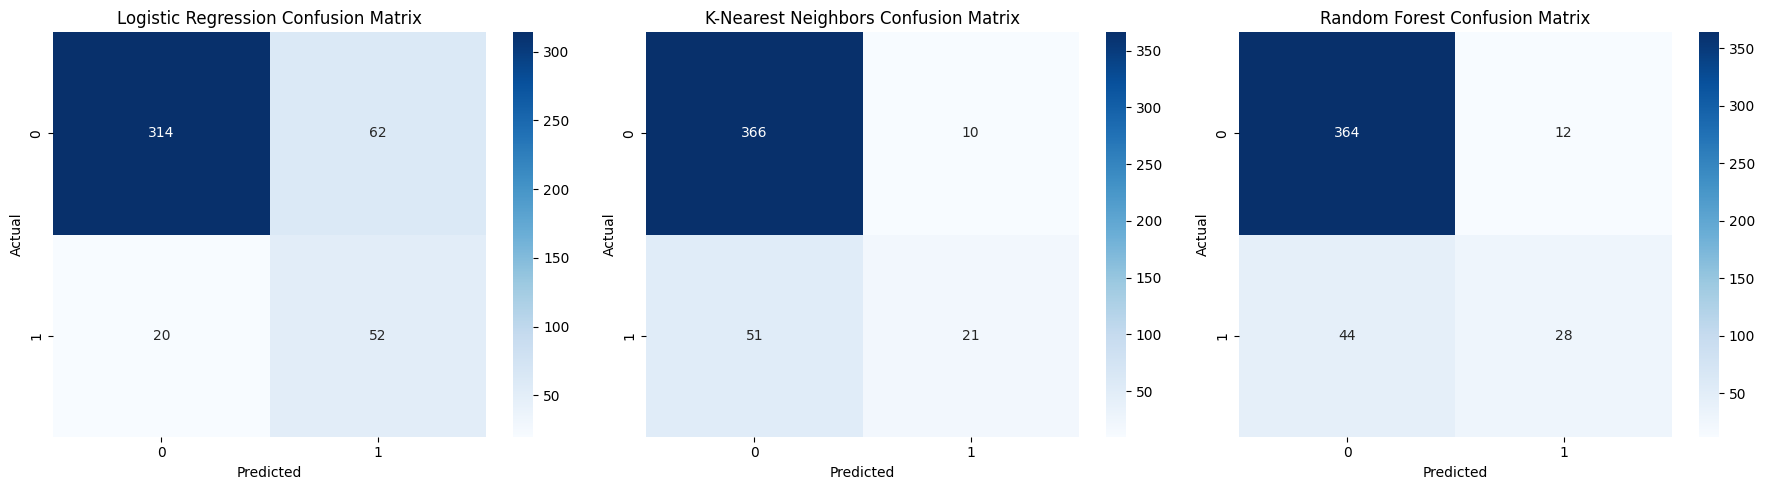

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#  Class Imbalance
print("Class Distribution for Target 'Response':")
print(df['Response'].value_counts())
print("-" * 50)

#  تحديد المتغير المستهدف y والميزات x للتصنيف
y_cls = df['Response']
# نستبعد الأعمدة غير الرقمية والـ ID والهدف نفسه
exclude_cls_cols = ['ID', 'Dt_Customer', 'Response']
X_cls = df.drop(columns=exclude_cls_cols)

#  تقسيم البيانات بنسبة 80/20
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

# تدرج الميزات Scaling للموديلات التي تعتمد على المسافات Logistic Regression & KNN
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

#  تعريف النماذج المطلوبة
classification_models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

#  تدريب وتقييم كل نموذج
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(classification_models.items()):
    # نستخدم البيانات المقاسة Scaled للـ Logistic و KNN والبيانات العادية للـ Random Forest
    if name == "Random Forest":
        model.fit(X_train_c, y_train_c)
        y_pred_c = model.predict(X_test_c)
    else:
        model.fit(X_train_c_scaled, y_train_c)
        y_pred_c = model.predict(X_test_c_scaled)

    # طباعة تقرير التصنيف
    print(f"Classification Report for {name} ")
    print(classification_report(y_test_c, y_pred_c))
    print("-" * 50)

    #confusion Matrix
    cm = confusion_matrix(y_test_c, y_pred_c)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'{name} Confusion Matrix')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 4. Unsupervised Learning - Clustering

In this final section, we aim to segment the customer base using **K-Means Clustering** based on four key financial and demographic attributes: `TotalSpending`, `Income`, `Age`, and `TotalChildren`.

### Steps Performed:
1. **Feature Selection & Scaling:** Extracted the 4 features and standardized them using `StandardScaler` to ensure equal feature weight.
2. **The Elbow Method:** Iterated through cluster counts ($k$ from 1 to 10) to find the optimal number of clusters by minimizing inertia.
3. **K-Means Fitting:** Trained the model with the chosen $k$ and labeled the original dataset.
4. **Dimensionality Reduction (PCA):** Reduced the 4D space into 2D principal components to visualize the distinct customer segments.
5. **Cluster Profiling:** Analyzed the mean values of each segment to provide actionable marketing profiles.

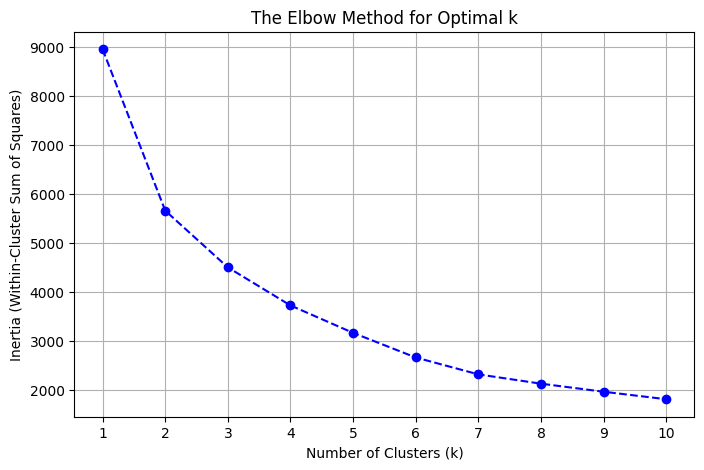

In [16]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

#  اختيار الميزات الأربعة المحددة للـ Clustering
cluster_features = ['TotalSpending', 'Income', 'Age', 'TotalChildren']
X_cluster = df[cluster_features]

# Scaling
scaler_cl = StandardScaler()
X_cluster_scaled = scaler_cl.fit_transform(X_cluster)

# Elbow Method
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)

# رسم المنحنى البياني
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

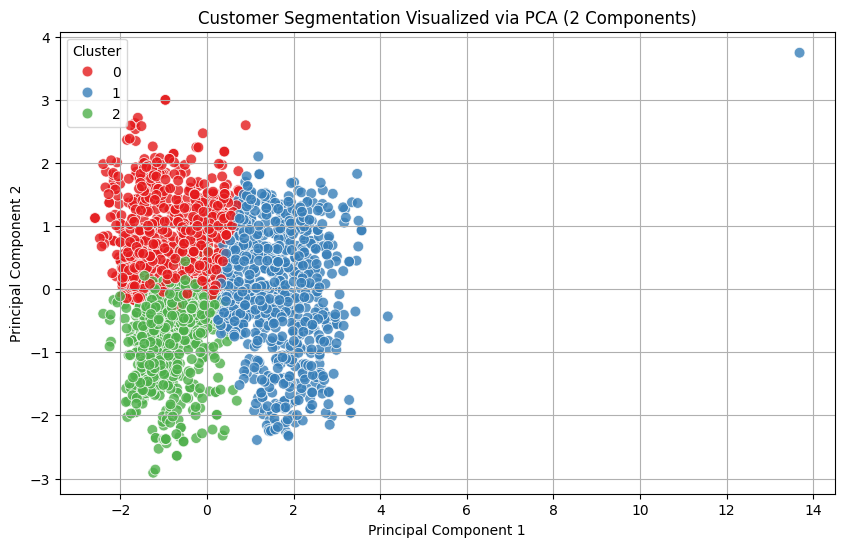

 Cluster Profiles (Mean Values) 
         TotalSpending        Income        Age  TotalChildren
Cluster                                                       
0           298.545070  47278.929577  63.940845       1.690141
1          1289.276382  74150.170854  58.640704       0.391960
2           159.804378  33161.607387  48.772914       0.841313


In [17]:
from sklearn.decomposition import PCA
import pandas as pd
import seaborn as sns

# تثبيت الـ K-Means بناءً على الـ k=3 المختارة
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_transform(X_cluster_scaled).argmin(axis=1) # إضافة الليبل للـ Dataframe الأصلي

# تقليل الأبعاد إلى 2D باستخدام PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

# إنشاء DataFrame مخصص للرسم
df_pca = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
df_pca['Cluster'] = df['Cluster'].values

#  رسم الـ 2D Scatter Plot الملون حسب المجموعات
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df_pca, palette='Set1', s=60, alpha=0.8)
plt.title('Customer Segmentation Visualized via PCA (2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

#  Cluster Profiling
cluster_profiles = df.groupby('Cluster')[cluster_features].mean()
print(" Cluster Profiles (Mean Values) ")
print(cluster_profiles)

### Cluster Profiling & Marketing Insights:

Based on the mean values obtained, our customer base is divided into three highly distinct strategic segments:

1. **Cluster 0: "Mature/Senior Established Families"**
   * **Profile:** Highest average age (64 years old) and the highest number of children/teens at home (~1.7). They have moderate income and moderate spending.
   * **Marketing Action:** Target them with family package offers, insurance/pension-linked promotions, and household essentials.

2. **Cluster 1: "High-Income, High-Spending VIP Customers"**
   * **Profile:** Highest income (~74,150) and by far the highest spending ($1,289). They have very few children (0.4).
   * **Marketing Action:** This is the most profitable segment. Target them with luxury products, exclusive wine tastings, premium meat deliveries, and VIP loyalty rewards.

3. **Cluster 2: "Younger, Budget-Conscious Small Families"**
   * **Profile:** Lowest average age (49 years old), lowest income (33,161), and lowest overall spending (~$159). They usually have 0 or 1 child.
   * **Marketing Action:** Target them with discounts, clearance sales, price-drop alerts, and value-for-money deals.